<a href="https://colab.research.google.com/github/BJut7021/TH_DeepLearning/blob/main/TH_DL_Lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install scikeras

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import tensorflow as tf
import keras
from keras.models import Sequential

from keras.layers import Convolution2D
from keras.layers import MaxPooling2D
from keras.layers import Flatten
from keras.layers import Dense
from scikeras.wrappers import KerasClassifier # Corrected import
from keras.layers import Dropout

from sklearn.metrics import f1_score, roc_auc_score, log_loss
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.preprocessing import MinMaxScaler


**3.2. Đọc tập dữ liệu FASHION MNIST**

In [4]:
fashion = tf.keras.datasets.fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion.load_data()
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


**3.3. Xử lý dữ liệu**

In [5]:
X_train = X_train.reshape(60000,784)
X_test = X_test.reshape((10000,784))

minmax = MinMaxScaler()
X_train = minmax.fit_transform(X_train)
X_test = minmax.transform(X_test)

print('Number of classes:',len(np.unique(y_train)))
print('Classes:',np.unique (y_train))

Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]


**3.4. Trực quan hóa dữ liệu**

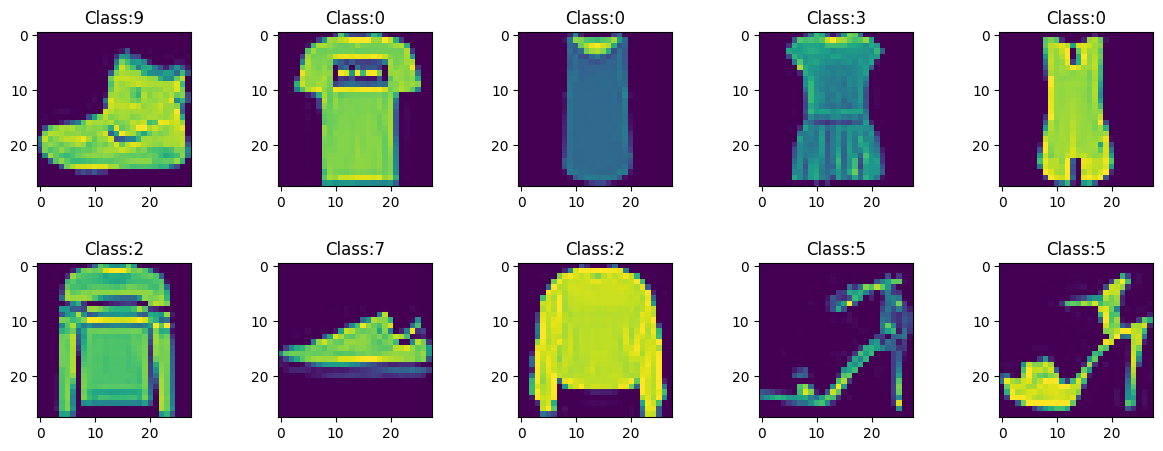

In [6]:

fig, axes = plt.subplots(2, 5, figsize=(15,5))
ax = axes.ravel()
for i in range(10):
  ax[i].imshow(X_train[i].reshape(28,28))
  ax[i].title.set_text('Class:'+str(y_train[i]))
plt.subplots_adjust(hspace=0.5)
plt.show()

**3.5. Xây dựng mô hình học ANN**

In [7]:

fashion_model = Sequential()

fashion_model.add(Dense(input_dim=X_train.shape[1], units=256, kernel_initializer='uniform',activation='relu'))

fashion_model.add(Dense(units=10,kernel_initializer='uniform', activation='softmax'))

fashion_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


fashion_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

**3.6. Huấn luyện ANN model**


In [8]:
model_fit = fashion_model.fit(X_train, y_train, validation_split=0.1, epochs=20, verbose=1)

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - accuracy: 0.8208 - loss: 0.5078 - val_accuracy: 0.8572 - val_loss: 0.3959
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8662 - loss: 0.3725 - val_accuracy: 0.8713 - val_loss: 0.3587
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8794 - loss: 0.3299 - val_accuracy: 0.8725 - val_loss: 0.3586
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8861 - loss: 0.3060 - val_accuracy: 0.8812 - val_loss: 0.3217
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.8952 - loss: 0.2864 - val_accuracy: 0.8820 - val_loss: 0.3271
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.8991 - loss: 0.2721 - val_accuracy: 0.8805 - val_loss: 0.3495
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9047 - loss: 0.2588 - val_accuracy: 0.8793 - val_loss: 0.3351
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9068 - loss:

**3.7. Đánh giá ANN model**

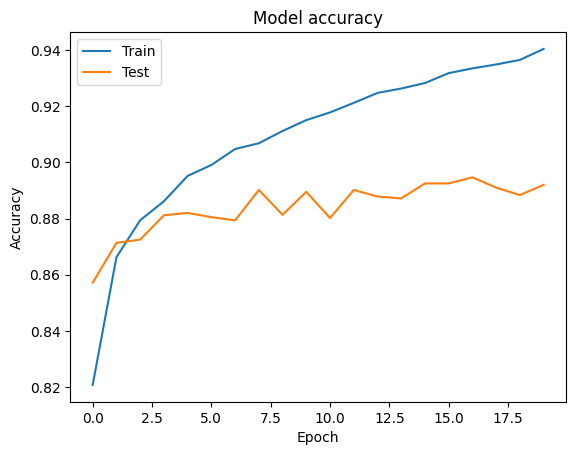

In [9]:
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()


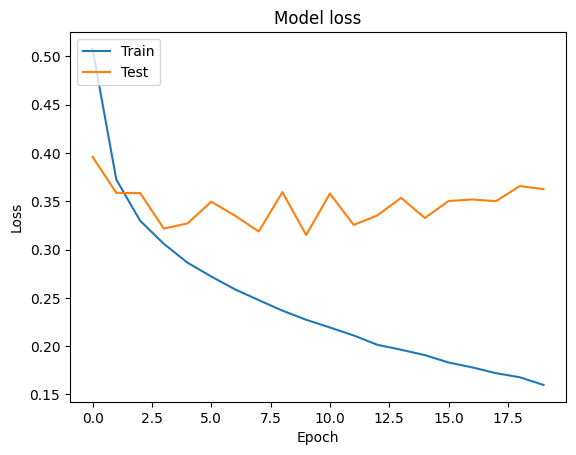

In [10]:
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

**3.8. Dự báo ảnh mới**

In [11]:
print(np.argmax(fashion_model.predict(X_test)[0]), y_test[0])
print(np.argmax(fashion_model.predict(X_test)[10]), y_test[10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
9 9
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
4 4


**3.9. Đọc tập dữ liệu từ file**

In [12]:
mnist_train_path = 'https://raw.githubusercontent.com/huynhhoc/DataAnalystDeepLearning/main/Data/crabs.csv'
mnist_test_path = 'https://raw.githubusercontent.com/huynhhoc/DataAnalystDeepLearning/main/Data/babies.csv'
mnist_train = pd.read_csv(mnist_train_path, sep=r'\s+', engine='python', na_values=['NA']) # Use raw URL and specify space as delimiter
mnist_test = pd.read_csv(mnist_test_path, sep=r'\s+', engine='python', na_values=['NA']) # Use raw URL and specify space as delimiter


print(mnist_train.head())
print(mnist_test.shape)

   presz  postsz   inc  year  lf
0  113.6   127.7  14.1   NaN   0
1  118.1   133.2  15.1   NaN   0
2  119.9   135.3  15.4   NaN   0
3  126.2   143.3  17.1   NaN   0
4  126.7   139.3  12.6   NaN   0
(1236, 2)


In [13]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import numpy as np

# We will use mnist_train (crabs.csv) for both training and testing.
# Make a copy to avoid SettingWithCopyWarning
data_crabs = mnist_train.copy()

# Fill NaN values in 'year' column with the median
# The 'year' column contains integer-like values, so median is appropriate.
median_year = data_crabs['year'].median()
data_crabs['year'].fillna(median_year, inplace=True)
data_crabs['year'] = data_crabs['year'].astype(int) # Convert to int if desired

# Extract features (X) and target (y) from crabs.csv
# Features are 'presz', 'postsz', 'inc', 'year'
X = data_crabs.iloc[:, :-1] # All columns except the last ('lf')
y = data_crabs.iloc[:, -1]  # Last column ('lf') as target

# Perform a train-test split on the crabs.csv data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# Added stratify=y to ensure both classes are present in train/test splits

# y (lf column) contains 0s and 1s, which are already 0-indexed and appropriate for binary classification.
# LabelEncoder is not strictly needed here as labels are already 0 and 1.

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

print('Number of classes (y_train):', len(np.unique(y_train)))
print('Classes (y_train encoded):', np.unique(y_train))

X_train shape: (377, 4)
y_train shape: (377,)
X_test shape: (95, 4)
y_test shape: (95,)
Number of classes (y_train): 2
Classes (y_train encoded): [0 1]


/tmp/ipykernel_10850/1460908316.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_crabs['year'].fillna(median_year, inplace=True)


In [14]:
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Dense


In [15]:
model = Sequential()
model.add(Dense(input_dim=X_train.shape[1], units=256, kernel_initializer='uniform',activation='relu'))
# For binary classification (labels 0 and 1), use 1 unit with 'sigmoid' activation
model.add(Dense(units=1, kernel_initializer='uniform', activation='sigmoid'))
# For 1 unit with 'sigmoid' activation, use 'binary_crossentropy' loss
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 256)            │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,537 (6.00 KB)

 Trainable params: 1,537 (6.00 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
model_fit = model.fit(X_train , y_train, epochs=30, verbose=1)

Epoch 1/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7639 - loss: 0.5987
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7507 - loss: 0.6086 
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7215 - loss: 0.5682 
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7639 - loss: 0.4804 
Epoch 5/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7692 - loss: 0.4727 
Epoch 6/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7613 - loss: 0.4816 
Epoch 7/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7692 - loss: 0.4526 
Epoch 8/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7560 - loss: 0.4423
Epoch 9/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8196 - loss: 0.4351 
Epoch 10/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7825 - loss: 0.4535 
Epoch 11/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7719 - loss: 0.4389
Epoch 12/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7

In [17]:
predicted_label = np.round(model.predict(X_test)[0])
actual_label = y_test.iloc[0]
print(predicted_label, actual_label)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
[1.] 1


In [26]:
img_path = r'/content/696249800_18089713175255130_453296426341664759_n.jpg'
img_size = (28,28)
img = tf.keras.preprocessing.image.load_img(img_path, target_size=img_size, color_mode='grayscale')
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = tf.squeeze(img_array)
img = np.reshape(img_array,(784))
img_array = tf.expand_dims(img,0)
img_array = tf.convert_to_tensor(img_array, dtype=tf.float32)
print(img_array.shape)

img_predict = fashion_model.predict(img_array)
print(img_predict)
score = np.argmax(img_predict)
print(score)

(1, 784)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
[[0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]]
8


**Bài tập**